<a href="https://colab.research.google.com/github/kalex066/DataScience---ProyectoFinal/blob/main/EDA/HarryPotterSorting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Harry Potter Sorting**
**🎯 Objetivo**

El objetivo principal es construir un modelo de clasificación capaz de predecir a qué casa de Hogwarts (Gryffindor, Hufflepuff, Ravenclaw o Slytherin) pertenece un estudiante basándose en sus atributos cualitativos y cuantitativos.


**📜 Descripción del Dataset**

Este conjunto de datos contiene información ficticia de 1000 estudiantes del Colegio Hogwarts de Magia y Hechicería. El dataset está diseñado para simular las características personales, habilidades académicas y rasgos de personalidad de los estudiantes, con el fin de modelar el proceso de selección del "Sombrero Seleccionador".

https://www.kaggle.com/datasets/sahityapalacharla/harry-potter-sorting-dataset



**🏁 Target (Variable Objetivo)**

`house`: Variable categórica que representa la casa a la que pertenece el estudiante.Clases: Gryffindor, Hufflepuff, Ravenclaw, Slytherin.

**🧩 Problema que Resuelve:**

Este dataset permite abordar un problema de clasificación multiclase. Al analizar las correlaciones entre los rasgos de personalidad (valentía, ambición, intelecto, lealtad) y el rendimiento académico, el modelo busca automatizar la lógica que utiliza el Sombrero Seleccionador y asignar cada estudiante a la casa que le es mas afin.

**📖 Diccionario de Datos**

|Variable|Tipo de Dato|Descripción|
|:---|:---|:---|
|`Blood_status`|Categorica|Estatus de sangre ((Half-blood, Muggle-born, Pure-blood))|
|`Bravery`|Numerica|Escala del 1-10 que mide la valentía|
|`Intelligence`|Numerica|Escala del 1-10 que mide la inteligencia/creatividad|
|`Loyalty`|Numerica|Escala del 1-10 que mide la lealtad|
|`Ambition`|Numerica|Escala del 1-10 que mide la ambición|
|`Dark Arts Knowledge`|Numerica|Escala del 1-10 que mide el nivel de conocimiento sobre Artes Oscuras|
|`Quidditch Skillse`|Numerica|Escala del 1-10 que mide la habilidad atlética en el deporte de Quidditch|
|`Dueling Skills`|Numerica|Escala del 1-10 que mide la destreza en el combate mágico (duelos)|
|`Creativity`|Numerica|Nivel de aptitud creativa del 1 al 10|
|`House`|Categorica|casa de Hogwarts (Target)|









# <font color='1890A3'>**SECCION 1. CARGA Y PRIMERA EXPLORACION**
**Cargar el dataset | head | tail | info | describe | shape** </font>

>## <font color='1890A3'>**Paso 1.1 Configuracion e importaciones** </font>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Configuración de estilos
plt.rcParams.update({
    'figure.facecolor': '#0F0F1A', 'axes.facecolor': '#1A1A2E',
    'axes.edgecolor': '#444',      'axes.labelcolor': '#CCC',
    'xtick.color': '#AAA',         'ytick.color': '#AAA',
    'text.color': 'white',         'grid.color': '#333',
    'grid.linestyle': '--',        'legend.facecolor': '#1A1A2E',
    'legend.edgecolor': '#444',
})


HOUSE_COLORS = {
    'Gryffindor': '#740001', # Burdeo
    'Slytherin':  '#1A472A', # Verde
    'Ravenclaw':  '#0E1A40', # Azul oscuro
    'Hufflepuff': '#ECB939'  # Amarillo/Dorado
}

MY_PALETTE = list(HOUSE_COLORS.values())

> ## <font color='1890A3'>**Paso 1.2 Cargar el dataset**</font>

In [2]:
df = pd.read_csv('/content/sample_data/harry_potter_1000_students.csv')

print(f'Dataset cargado exitosamente!')
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria aproximada: {df.memory_usage(deep=True).sum() / 1024:.0f} KB')
print(f'\nColumnas: {list(df.columns)}')

Dataset cargado exitosamente!
Dimensiones: 1000 filas x 10 columnas
Memoria aproximada: 178 KB

Columnas: ['Blood Status', 'Bravery', 'Intelligence', 'Loyalty', 'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity', 'House']


> ## <font color='1890A3'>**Paso 1.3 Primeras y Ultimas filas del Dataset**</font>

In [3]:
print('=== Primeras 5 filas ===')
display(df.head())
print('\n=== Ultimas 5 filas ===')
display(df.tail())

=== Primeras 5 filas ===


,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
0,Half-blood,9,4,7,5,0,8,8,7,Gryffindor
1,Muggle-born,6,8,5,7,5,6,4,9,Ravenclaw
2,Pure-blood,1,4,7,7,1,4,4,6,Hufflepuff
3,Pure-blood,9,1,3,4,1,9,10,1,Gryffindor
4,Muggle-born,5,9,7,3,3,6,7,9,Ravenclaw



=== Ultimas 5 filas ===


,Blood Status,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity,House
995,Half-blood,7,10,3,7,1,1,3,8,Ravenclaw
996,Pure-blood,7,3,2,7,8,6,7,7,Slytherin
997,Half-blood,5,10,5,3,3,5,7,10,Ravenclaw
998,Half-blood,5,6,10,4,4,6,2,4,Hufflepuff
999,Half-blood,7,1,10,5,3,0,3,3,Hufflepuff


> ## <font color='1890A3'>**Paso 1.4 Estructura General del Dataset**</font>

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Blood Status         1000 non-null   object
 1   Bravery              1000 non-null   int64 
 2   Intelligence         1000 non-null   int64 
 3   Loyalty              1000 non-null   int64 
 4   Ambition             1000 non-null   int64 
 5   Dark Arts Knowledge  1000 non-null   int64 
 6   Quidditch Skills     1000 non-null   int64 
 7   Dueling Skills       1000 non-null   int64 
 8   Creativity           1000 non-null   int64 
 9   House                1000 non-null   object
dtypes: int64(8), object(2)
memory usage: 78.3+ KB


Sin Nulos

> ## <font color='1890A3'>**Paso 1.5 Estadisticas Descriptivas del Dataset**</font>

In [5]:
df.describe()
print('=== Columnas numericas ===')
display(df.describe())
print('\n=== Columnas categoricas ===')
display(df.describe(include='object'))


=== Columnas numericas ===


,Bravery,Intelligence,Loyalty,Ambition,Dark Arts Knowledge,Quidditch Skills,Dueling Skills,Creativity
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,5.026000,5.28100,5.129000,5.136000,4.040000,5.46000,6.223000,5.208000
std,2.682633,2.66179,2.695111,2.716041,3.112248,2.74881,2.833249,2.730969
min,1.000000,1.00000,1.000000,1.000000,0.000000,0.00000,1.000000,1.000000
25%,3.000000,3.00000,3.000000,3.000000,1.000000,4.00000,4.000000,3.000000
50%,5.000000,5.00000,5.000000,5.000000,3.000000,6.00000,7.000000,5.000000
75%,7.000000,7.00000,7.000000,7.000000,7.000000,7.00000,9.000000,7.000000
max,10.000000,10.00000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000



=== Columnas categoricas ===


,Blood Status,House
count,1000,1000
unique,3,4
top,Half-blood,Slytherin
freq,355,265


# <font color='1890A3'>**SECCION 2. LIMPIEZA DE DATOS**
**tipos | duplicados | inconsistencias | nulos | outliers** </font>

> ## <font color='1890A3'>**Paso 2.1 Verificar y corregir tipos de datos**</font>

In [6]:
print('Tipos de Datos ANTES de limpiar:')
print(df.dtypes)
print()

Tipos de Datos ANTES de limpiar:
Blood Status           object
Bravery                 int64
Intelligence            int64
Loyalty                 int64
Ambition                int64
Dark Arts Knowledge     int64
Quidditch Skills        int64
Dueling Skills          int64
Creativity              int64
House                  object
dtype: object



Cambiare el tipo de dato a categorico de `Blood Staus` y `House`

In [7]:
df['Blood Status'] = df['Blood Status'].astype('category')
df['House'] = df['House'].astype('category')

print('Tipos de Datos DESPUES de limpiar:')
print(df.dtypes)

Tipos de Datos DESPUES de limpiar:
Blood Status           category
Bravery                   int64
Intelligence              int64
Loyalty                   int64
Ambition                  int64
Dark Arts Knowledge       int64
Quidditch Skills          int64
Dueling Skills            int64
Creativity                int64
House                  category
dtype: object


> ## <font color='1890A3'>**Paso 2.2 Identificar y eliminar duplicados**</font>

In [9]:
n_total = len(df)
n_dupes = df.duplicated().sum()

print(f'Filas totales:           {n_total}')
print(f'Duplicados exactos:      {n_dupes} ({n_dupes/n_total*100:.1f}%)')

Filas totales:           1000
Duplicados exactos:      0 (0.0%)


> ## <font color='#1890A3'> **Paso 2.3 Inconsistencias en valores categoricos** </font>

In [10]:
df['Blood Status'] = df['Blood Status'].str.lower().str.strip()
df['House'] = df['House'].str.lower().str.strip()

df['Blood Status'] = df['Blood Status'].str.title()
df['House'] = df['House'].str.title()

print("Valores unicos en Blood Status:", df['Blood Status'].unique())
print("Houses unicas:", df['House'].unique())

Valores unicos en Blood Status: ['Half-Blood' 'Muggle-Born' 'Pure-Blood']
Houses unicas: ['Gryffindor' 'Ravenclaw' 'Hufflepuff' 'Slytherin']


> ## <font color='1890A3'>**Paso 2.4 Analisis de valores nulos**</font>

In [11]:
null_report = pd.DataFrame({
    'Nulos':      df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Nulos > 0').sort_values('Porcentaje', ascending=False)

null_report['Umbral'] = null_report['Porcentaje'].apply(
    lambda x: 'Imputar (< 30%)' if x < 30
    else ('Evaluar (30-50%)' if x < 50 else 'Eliminar columna (> 50%)')
)

print('=== Columnas con valores nulos ===')
display(null_report)
print(f"Valores nulos en el dataset: {df.isnull().sum().sum()}")

=== Columnas con valores nulos ===


,Nulos,Porcentaje,Umbral


Valores nulos en el dataset: 0


> ## <font color='#1890A3'>**Paso 2.5 Identificar y Eliminar Outliers** </font>

In [12]:
print('----- ANALISIS DE OUTLIERS -----')

# Valores imposibles las habilidades son de 0 a 10
cols_habilidades = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills',
                    'Creativity']

invalidos = df[
    (df[cols_habilidades] < 0).any(axis=1) |
    (df[cols_habilidades] > 10).any(axis=1)
]

print(f'Registros fuera de rango (0-10): {len(invalidos)} filas')

# 2. Definición de límites IQR para detectar outliers estadísticos
def get_iqr_limits(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

mascara_outliers = pd.Series(False, index=df.index)

for col in cols_habilidades:
    inf, sup = get_iqr_limits(df[col])
    mascara_outliers |= (df[col] < inf) | (df[col] > sup)

df_clean = df[~mascara_outliers].copy().reset_index(drop=True)

filas_eliminadas = len(df) - len(df_clean)
print(f'Filas eliminadas tras depuración (IQR): {filas_eliminadas}')
print(f'Dataset limpio final: {df_clean.shape[0]} filas x {df_clean.shape[1]} columnas')

----- ANALISIS DE OUTLIERS -----
Registros fuera de rango (0-10): 0 filas
Filas eliminadas tras depuración (IQR): 0
Dataset limpio final: 1000 filas x 10 columnas


> ## <font color='#1890A3'>**Paso 2.7 Eliminar Columnas Innecesarias** </font>
No se eliminaran columnas

> ## <font color='#1890A3'>**Paso 2.8 Resumen proceso de Limpieza** </font>

In [13]:
print('------ RESUMEN DEL DATASET LIMPIO ------')
filas_finales, columnas_finales = df_clean.shape
print("---------------------------------------------------------")
print(f"Dimensiones Finales : {filas_finales} filas x {columnas_finales} columnas")
print(f"Valores Nulos Totales: {df_clean.isnull().sum().sum()} (¡Dataset 100% limpio!)")
print("---------------------------------------------------------")
print("Conteo de Variables por Tipo de Dato:")
print(df_clean.dtypes.value_counts())
print("---------------------------------------------------------")

------ RESUMEN DEL DATASET LIMPIO ------
---------------------------------------------------------
Dimensiones Finales : 1000 filas x 10 columnas
Valores Nulos Totales: 0 (¡Dataset 100% limpio!)
---------------------------------------------------------
Conteo de Variables por Tipo de Dato:
int64     8
object    2
Name: count, dtype: int64
---------------------------------------------------------


# <font color='#1890A3'> **SECCION 3 EXPLORACION DE DATOS (EDA)**
**Univariante x2 | Multivariante x2 | Interpretacion** </font>

> ## <font color='#1890A3'>**Countplot para House**</font>

**Objetivo:** Entender la distribucion de la variable objetivo del analisis


In [31]:
df_counts = df['House'].value_counts().reset_index()
df_counts.columns = ['House', 'Count']

fig = px.bar(
    df_counts,
    x='House',
    y='Count',
    color='House',
    color_discrete_sequence=MY_PALETTE,
    text='Count',
    title='Distribución de Estudiantes por Casa'
)

fig.update_layout(
    template="plotly_dark",
    plot_bgcolor='#1A1A2E',
    paper_bgcolor='#0F0F1A',
    font=dict(color='white'),
    xaxis=dict(showgrid=False),
    yaxis=dict(showgrid=True, gridcolor='#333')
)

fig.update_traces(textposition='outside')

fig.show()

>**Analisis**

Las cuatro casas tienen una cantidad de alumnos equilibrada, entre 226 y 265), siendo Slytherin la que tiene mas alumnos. Esta distribucion indica que el modelo aprenderia de todas las casas.

> ## <font color='#1890A3'>**Heatmap de Habilidades de los estudiantes**</font>

**Objetivo:** Entender la relacion entre las habilidades de los estudiantes y el target (House)

In [25]:
cols = ['Bravery', 'Intelligence', 'Loyalty', 'Ambition', 'Dark Arts Knowledge', 'Quidditch Skills', 'Dueling Skills', 'Creativity']
fig = make_subplots(rows=2, cols=4, subplot_titles=cols)

for i, col in enumerate(cols):
    row, col_idx = (i // 4) + 1, (i % 4) + 1
    for house in df['House'].unique():
        df_house = df[df['House'] == house]
        fig.add_trace(go.Box(y=df_house[col], name=house, showlegend=(i==0)), row=row, col=col_idx)

fig.update_layout(height=800, title_text="Distribución de Habilidades por Casa", template="plotly_dark", showlegend=True)
fig.show()

> **Analisis**

Los estudiantes de Slytherin tienen mayor conocimiento en Artes Oscuras, Duelo, Quidditch y Ambicion.

Los estudiantes de Gryffindor tienen como habilidades destacadas Duelo, Quidditch y Valentia.

Los de Ravenclaw sobresalen en inteligencia y creatividad, mientras los de Hupplepuff en Lealtad.



> ## <font color='#1890A3'>**Boxplot: Distribucion de `Blood Status` por casa**</font>

**Objetivo:** Conocer como se distribuyen los alumnos con diferentes status de sangre dentro de cada una de las casas de Hogwarts


In [32]:
df_blood = df.groupby(['House', 'Blood Status']).size().reset_index(name='Count')

fig = px.bar(
    df_blood,
    x='House',
    y='Count',
    color='Blood Status',
    title='Distribución de Estatus de Sangre por Casa',
    barmode='stack',
    color_discrete_sequence=px.colors.qualitative.Pastel # Colores claros para contrastar con el fondo
)

fig.update_layout(template="plotly_dark", paper_bgcolor='#0F0F1A', plot_bgcolor='#1A1A2E')
fig.show()

> **Analisis**

Se observa una distribucion equitativa de estudiantes con los tres tipos de `Blood Status` dentro de cada casa, aunque muy ligeramente, en Hufllepuff hay una mayor cantidad de sangre pura, y en Slytherin de Half-Blood

> ## <font color='#1890A3'>**ScatterPlot entre Bravery e Intelligence**</font>

**Objetivo:** Entender la relacion entre estas variables


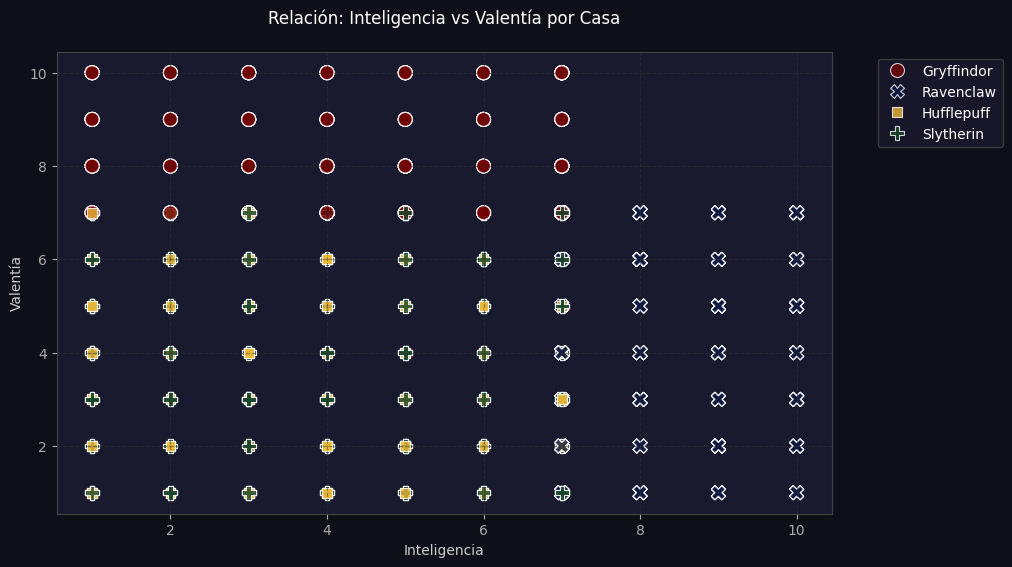

In [45]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='Intelligence',
    y='Bravery',
    hue='House',
    palette=HOUSE_COLORS,
    style='House',
    s=100,
    alpha=0.8
)

plt.title('Relación: Inteligencia vs Valentía por Casa', color='white', pad=20)
plt.xlabel('Inteligencia', color='#CCC')
plt.ylabel('Valentía', color='#CCC')
plt.grid(color='#333', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', facecolor='#1A1A2E', labelcolor='white')

plt.show()

> **Analisis**

Gryffindor (círculos rojos), se concentran en valores altos de valentía (7–10),
La inteligencia varía más, desde media hasta alta. Prioriza la valentía, aunque no necesariamente descuida la inteligencia.

Ravenclaw (cruces azules), se ubican en la zona de alta inteligencia (7–10) pero la valentia es más dispersa, desde baja hasta media-alta.Ravenclaw destaca por el intelecto, con valentía menos consistente.

Hufflepuff (cuadrados amarillos), con distribución bastante equilibrada, con valores medios en ambos ejes. No sobresalen en extremos, lo que sugiere constancia y balance.

Slytherin (signos verdes +), la Inteligencia tiende a ser alta (6–9) pero la Valentía es más variable, pero no tan extrema como Gryffindor.
Se nota un énfasis en la astucia y estrategia más que en la bravura pura.

**Comparación entre casas**
Gryffindor vs Ravenclaw: valentía vs inteligencia como rasgos dominantes.

Hufflepuff: equilibrio sin extremos.

Slytherin: inteligencia alta con valentía moderada, lo que sugiere pragmatismo.



#**📊 Hallazgos y Desafios**

**- Hallazgos Clave**

***Segmentación por Habilidades:*** Las casas no son aleatorias. Existen correlaciones claras: las casas poseen "perfiles de personalidad" definidos (ej. niveles altos de Bravery en Gryffindor vs. Intelligence en Ravenclaw).

***Composición Demográfica:*** No existe una segregación social en las casas.

***Distribución del Target:*** Las clases estan balanceadas, el modelo aprendera de las caracteristicas de los estudiantes de todas las casas por igual.

**🚧 Desafíos**

***Codificación de Variables:*** Transformar House y Blood Status de texto a números.

***Estandarización:*** Como las habilidades están en escala 0-10, los modelos basados en distancias (KNN, SVM) exigirán que normalices los datos a una escala común (0 a 1).

***Generalización:*** El mayor riesgo es el overfitting (que el modelo memorice tus 1000 estudiantes en lugar de aprender el patrón del Sombrero Seleccionador).
